                                            SPEECH RECOGNITION

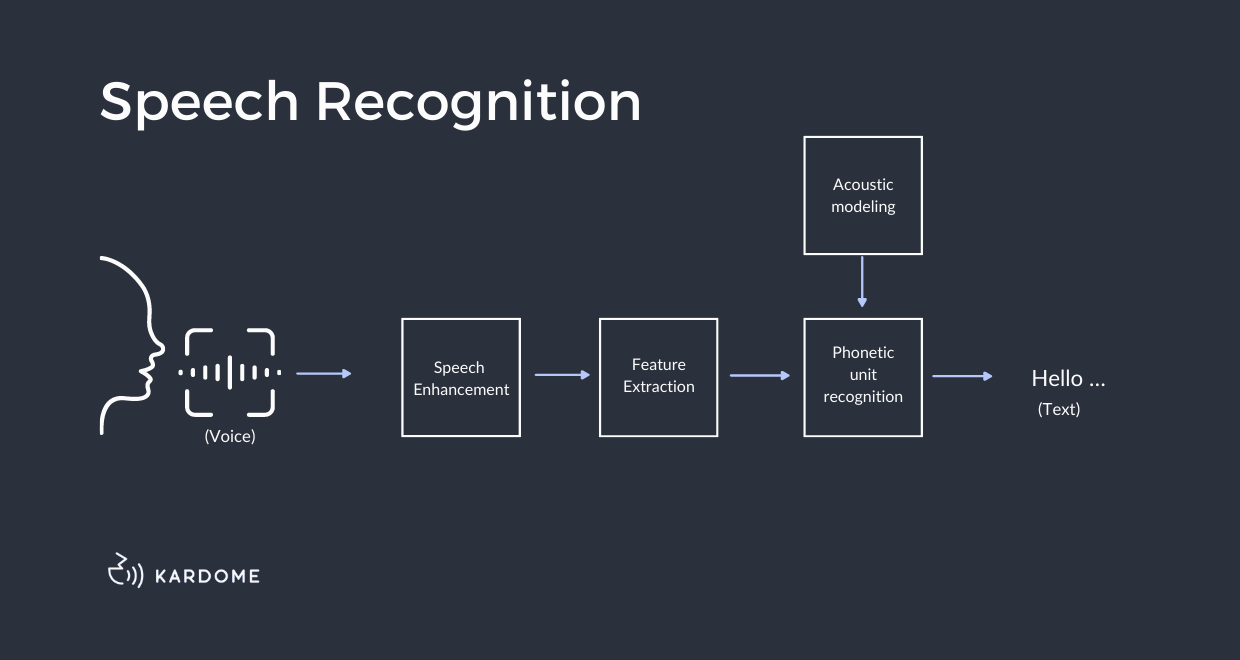

In [1]:
import sys
print(sys.executable)


/data/upasana/venv/bin/python


In [2]:
import torch
torch.cuda.is_available()


True

In [3]:
import torch, numpy, pandas
print(torch.__version__)
print(numpy.__version__)
print(pandas.__version__)

2.7.1+cu118
2.2.6
2.3.3


What is Speech Recognition:

Speech recognition, also known as automatic speech recognition (ASR) or voice recognition, is a technology that converts spoken language into written text. 

Here are the key steps in a short summary:

Acquisition of Audio Input: Capture audio signals using a microphone or other recording device.

Preprocessing: Clean and preprocess the audio data to enhance signal quality, removing noise or distortions.

Feature Extraction: Extract relevant features from the audio signal, such as spectral features or Mel-frequency cepstral coefficients (MFCCs).

Model Training: Train a speech recognition model using machine learning algorithms, often deep neural networks, on a labeled dataset containing pairs of audio samples and their corresponding transcriptions.

Decoding: Apply the trained model to decode or transcribe the input audio into text.

Post-processing: Refine the transcription results, applying techniques such as language modeling or context-aware algorithms.

Output: Obtain the final transcribed text as the output of the speech recognition system.

Speech recognition is used in various applications, including voice assistants, transcription services, and hands-free operation of devices.

## INTRODUCTION

WHAT WE WILL COVER IN THIS PROJECT:

1) Speech Recognition-speech to text, text to speech and translation:

    a) Capture spoken audio and display the transcription(predicted text)
    
    b) Enrich audio by volume and background nosie adjustments
    
    c) Compare transcription to actual text.Utilize WER score.
    
    d) Translate the transcribed text into another language(French and Turkish).
    
    e) Listen to the audio of translated text
    
2) Speech Recognition-prediction of gender from audio files:

    a) Visualize audio files for key indicators for gender recognition.
    
    b) Extract key features from audio files to input into model training.
    
    c) Train and evaluate a neural network model to predict the gender for audio files.
    
    
We are provided with many short audio files to be used for this project. For our translation section, we will only use handful of these files to showcase and for gender prediction, we will be using a subset(10,000) of the training data that is provided. A separate csv file is provided that has the audio file names, actual spoken text, gender, age of speaker and few other datapoints to assist with the project.

## Part 1 - Speech to text, text to speech and translation

Importing libraries and the csv file

In [4]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [5]:
# Specify the file path
file_path = "/data/upasana/cv-valid-train.csv"

# Read the CSV file into a DataFrame
dftrain = pd.read_csv(file_path)
dftrain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195776 entries, 0 to 195775
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   filename    195776 non-null  object 
 1   text        195776 non-null  object 
 2   up_votes    195776 non-null  int64  
 3   down_votes  195776 non-null  int64  
 4   age         73768 non-null   object 
 5   gender      74059 non-null   object 
 6   accent      64711 non-null   object 
 7   duration    0 non-null       float64
dtypes: float64(1), int64(2), object(5)
memory usage: 11.9+ MB


There are many blanks on few of the columns, for predicting gender, we will only use the rows that have the data.

In [6]:
# Set the option to display maximum column width
pd.set_option('display.max_colwidth', None)
dftrain.head()

,filename,text,up_votes,down_votes,age,gender,accent,duration
0,cv-valid-train/sample-000000.mp3,learn to recognize omens and follow them the old king had said,1,0,NaN,NaN,NaN,NaN
1,cv-valid-train/sample-000001.mp3,everything in the universe evolved he said,1,0,NaN,NaN,NaN,NaN
2,cv-valid-train/sample-000002.mp3,you came so that you could learn about your dreams said the old woman,1,0,NaN,NaN,NaN,NaN
3,cv-valid-train/sample-000003.mp3,so now i fear nothing because it was those omens that brought you to me,1,0,NaN,NaN,NaN,NaN
4,cv-valid-train/sample-000004.mp3,if you start your emails with greetings let me be the first to welcome you to earth,3,2,NaN,NaN,NaN,NaN


Lets listen to the first 10 audio files in our training folder. We obserbe that some file have very low volume along with background noise which will be challenging to perfrom speech to text tasks. Click play to play the audio.

In [7]:
!pip install pydub

In [8]:
from IPython.display import display, Audio
import os
from pydub import AudioSegment

# Function to play audio file
def play_audio(audio_path):
    display(Audio(filename=audio_path))

# Specify the folder path containing MP3 files
folder_path = '/data/upasana/cv-valid-train/cv-valid-train'

# Get the list of all files in the folder and sort them
all_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.mp3')])

# Get the total file count
total_files = len(all_files)
print(f'Total number of MP3 files in the folder: {total_files}')

# Play the first two audio files
for i in range(min(10, len(all_files))):
    file_path = os.path.join(folder_path, all_files[i])
    audio = AudioSegment.from_mp3(file_path)
    
    print(f'Playing file: {all_files[i]}')
    play_audio(file_path)

Total number of MP3 files in the folder: 195776
Playing file: sample-000000.mp3


Playing file: sample-000001.mp3


Playing file: sample-000002.mp3


Playing file: sample-000003.mp3


Playing file: sample-000004.mp3


Playing file: sample-000005.mp3


Playing file: sample-000006.mp3


Playing file: sample-000007.mp3


Playing file: sample-000008.mp3


Playing file: sample-000009.mp3


In [9]:
import os
import numpy as np
import pandas as pd
import librosa
from sklearn.model_selection import train_test_split

csv_path = '/data/upasana/cv-valid-train.csv'
audio_folder = '/data/upasana/cv-valid-train/cv-valid-train'

df = pd.read_csv(csv_path)
df = df[['filename', 'text']].dropna().reset_index(drop=True)

def extract_log_mel(
    audio_path,
    target_sr=16000,
    n_mels=80,
    n_fft=400,
    hop_length=160,
    max_seconds=15.0
):
    """Returns Log-Mel Spectrogram features of shape (time_steps, n_mels)"""
    audio, sr = librosa.load(audio_path, sr=target_sr)

    if max_seconds is not None:
        max_len = int(target_sr * max_seconds)
        if len(audio) > max_len:
            audio = audio[:max_len]

    if len(audio) > 0:
        audio = (audio - np.mean(audio)) / (np.std(audio) + 1e-9)

    mel_spec = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=n_mels,
        n_fft=n_fft,
        hop_length=hop_length,
        fmin=0,
        fmax=target_sr // 2
    )

    log_mel = librosa.power_to_db(mel_spec, ref=np.max)
    return log_mel.T

# Increase samples for better accuracy if available
rows = df.copy()
# Train/Val split
train_rows, val_rows = train_test_split(rows, test_size=0.1, random_state=42, shuffle=True)
print("Train samples:", len(train_rows))
print("Val samples:", len(val_rows))


Train samples: 176198
Val samples: 19578


In [10]:
import string

# Blank token for CTC
BLANK_TOKEN = "_"

# Use a standard set that can construct any medical term via characters
# Adding numbers is vital for dosages later
chars = list(string.ascii_lowercase) + list(string.digits) + [" ", "'", ".", ","]

vocab = {BLANK_TOKEN: 0}
for i, ch in enumerate(chars, start=1):
    vocab[ch] = i

idx2char = {i: ch for ch, i in vocab.items()}
vocab_size = len(vocab)

In [11]:
def encode_transcript(text, vocab):
    text = text.lower()
    return [vocab[ch] for ch in text if ch in vocab]
print(encode_transcript("hello world", vocab))


[8, 5, 12, 12, 15, 37, 23, 15, 18, 12, 4]


In [12]:
# Encoding is now done lazily inside SpeechDataset.__getitem__
# to avoid storing all targets and mels in RAM.


In [13]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

MAX_FRAMES = 1200  # ~12s at 10ms hop

class SpeechDataset(Dataset):
    def __init__(self, df_rows, audio_folder, vocab, max_seconds=12.0, cache_dir="/data/upasana/mel_cache"):
        self.df = df_rows
        self.audio_folder = audio_folder
        self.vocab = vocab
        self.max_seconds = max_seconds
        self.cache_dir = cache_dir
        os.makedirs(self.cache_dir, exist_ok=True)

    def __len__(self):
        return len(self.df)

    def _cache_path(self, filename):
        base = os.path.splitext(os.path.basename(filename))[0]
        return os.path.join(self.cache_dir, f"{base}.npy")

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = os.path.basename(row['filename'])
        transcript = row['text']
        audio_path = os.path.join(self.audio_folder, filename)

        cache_path = self._cache_path(filename)
        if os.path.exists(cache_path):
            mel = np.load(cache_path)
        else:
            mel = extract_log_mel(audio_path, max_seconds=self.max_seconds)
            if mel.shape[0] > MAX_FRAMES:
                mel = mel[:MAX_FRAMES]
            np.save(cache_path, mel)

        if mel.shape[0] > MAX_FRAMES:
            mel = mel[:MAX_FRAMES]

        target = torch.tensor(encode_transcript(transcript, vocab), dtype=torch.long)
        if target.numel() == 0:
            return None
        if target.numel() > mel.shape[0]:
            return None

        mel = torch.tensor(mel, dtype=torch.float32)

        return {
            "mel": mel,
            "target": target,
            "input_length": mel.shape[0],
            "target_length": target.shape[0]
        }


def collate_fn(batch):
    batch = [b for b in batch if b is not None]
    if len(batch) == 0:
        return None

    mels, targets = [], []
    input_lengths, target_lengths = [], []

    for item in batch:
        mel = item["mel"]
        tgt = item["target"]

        mels.append(mel)
        targets.append(tgt)
        input_lengths.append(mel.shape[0])
        target_lengths.append(tgt.shape[0])

    mels_padded = pad_sequence(mels, batch_first=True, padding_value=-20.0)
    targets_padded = pad_sequence(targets, batch_first=True, padding_value=0)

    return (
        mels_padded,
        targets_padded,
        torch.tensor(input_lengths),
        torch.tensor(target_lengths),
    )


def build_length_buckets(df_rows, audio_folder, target_sr=16000, max_seconds=12.0):
    lengths = []
    for i, row in df_rows.iterrows():
        filename = os.path.basename(row['filename'])
        audio_path = os.path.join(audio_folder, filename)
        try:
            dur = librosa.get_duration(path=audio_path)
        except Exception:
            dur = max_seconds
        if max_seconds is not None:
            dur = min(dur, max_seconds)
        frames = int(dur * target_sr / 160)
        lengths.append(frames)
    return lengths


class LengthBucketBatchSampler(torch.utils.data.Sampler):
    def __init__(self, lengths, batch_size, shuffle=True):
        self.lengths = lengths
        self.batch_size = batch_size
        self.shuffle = shuffle

    def __iter__(self):
        indices = list(range(len(self.lengths)))
        indices.sort(key=lambda i: self.lengths[i])
        buckets = [indices[i:i + self.batch_size] for i in range(0, len(indices), self.batch_size)]
        if self.shuffle:
            np.random.shuffle(buckets)
        for b in buckets:
            yield b

    def __len__(self):
        return (len(self.lengths) + self.batch_size - 1) // self.batch_size


# Datasets
train_dataset = SpeechDataset(train_rows, audio_folder, vocab, cache_dir="/data/upasana/mel_cache_train")
val_dataset = SpeechDataset(val_rows, audio_folder, vocab, cache_dir="/data/upasana/mel_cache_val")

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

# Bucketing
train_lengths = build_length_buckets(train_rows, audio_folder)
val_lengths = build_length_buckets(val_rows, audio_folder)

print("Train length stats:", min(train_lengths), max(train_lengths), "frames")
print("Val length stats:", min(val_lengths), max(val_lengths), "frames")

batch_size = 32
train_sampler = LengthBucketBatchSampler(train_lengths, batch_size=batch_size, shuffle=True)
val_sampler = LengthBucketBatchSampler(val_lengths, batch_size=batch_size, shuffle=False)

train_loader = DataLoader(
    train_dataset,
    batch_sampler=train_sampler,
    collate_fn=collate_fn,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_sampler=val_sampler,
    collate_fn=collate_fn,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

# Sanity-check one batch
for batch in train_loader:
    if batch is None:
        continue
    mels, targets, input_lengths, target_lengths = batch
    print("Batch mel shape:", mels.shape)
    print("Batch target shape:", targets.shape)
    print("Input lengths:", input_lengths[:5])
    print("Target lengths:", target_lengths[:5])
    break


Train samples: 176198
Val samples: 19578


/data/upasana/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train length stats: 74 1200 frames
Val length stats: 86 1200 frames
Batch mel shape: torch.Size([32, 358, 80])
Batch target shape: torch.Size([32, 65])
Input lengths: tensor([358, 358, 358, 358, 358])
Target lengths: tensor([35, 49, 35, 24, 64])


In [14]:
import torch
import torch.nn as nn
import numpy as np

def greedy_decode(logits, input_lengths, blank=0):
    """
    logits: (B, T, vocab)
    input_lengths: (B,)
    """
    preds = logits.argmax(dim=-1)  # (B, T)
    results = []

    T_max = preds.size(1)

    for b in range(preds.size(0)):
        seq = []
        prev = blank

        # ---- CRITICAL FIX: clamp length ----
        length = min(input_lengths[b].item(), T_max)

        for t in range(length):
            p = preds[b, t].item()
            if p != blank and p != prev:
                seq.append(p)
            prev = p

        results.append(seq)

    return results



def cer(preds, targets):
    """
    preds, targets: list of int lists
    """
    def edit_distance(a, b):
        dp = np.zeros((len(a)+1, len(b)+1))
        for i in range(len(a)+1): dp[i][0] = i
        for j in range(len(b)+1): dp[0][j] = j
        for i in range(1, len(a)+1):
            for j in range(1, len(b)+1):
                dp[i][j] = min(
                    dp[i-1][j] + 1,
                    dp[i][j-1] + 1,
                    dp[i-1][j-1] + (a[i-1] != b[j-1])
                )
        return dp[-1][-1]

    total_edits, total_chars = 0, 0
    for p, t in zip(preds, targets):
        total_edits += edit_distance(p, t)
        total_chars += len(t)

    return total_edits / total_chars
import torch
from collections import defaultdict


def ctc_beam_search_decode(logits, beam_width=10, blank=0):
    """
    Performs CTC Prefix Beam Search.
    logits: (B, T, V) - Logits from the model (before softmax)
    beam_width: Number of active hypotheses to maintain
    blank: Index of the blank token
    """
    # 1. Convert logits to probabilities
    probs = torch.softmax(logits, dim=-1)
    batch_size, T, V = probs.shape
    results = []

    for b in range(batch_size):
        # beam format: {prefix: (p_blank, p_non_blank)}
        # p_blank: prob that the prefix ends in a CTC blank
        # p_non_blank: prob that the prefix ends in a real character
        beam = {(): (1.0, 0.0)}

        for t in range(T):
            new_beam = defaultdict(lambda: (0.0, 0.0))
            
            # Iterate over the top V tokens at this time step to save time
            # Using top 20 tokens is usually enough for medical precision
            top_probs, top_indices = torch.topk(probs[b, t], min(20, V))

            for char_idx, char_prob in zip(top_indices, top_probs):
                char_idx = char_idx.item()
                char_prob = char_prob.item()

                for prefix, (p_b, p_nb) in beam.items():
                    # Case 1: We encounter a blank token
                    if char_idx == blank:
                        n_p_b, n_p_nb = new_beam[prefix]
                        new_beam[prefix] = (n_p_b + char_prob * (p_b + p_nb), n_p_nb)
                    
                    else:
                        end_char = prefix[-1] if prefix else None
                        n_prefix = prefix + (char_idx,)
                        n_p_b, n_p_nb = new_beam[n_prefix]

                        # Case 2: Repeated character (e.g., 'a' followed by 'a')
                        if char_idx == end_char:
                            # If they were separated by a blank, it's a new char
                            new_beam[n_prefix] = (n_p_b, n_p_nb + char_prob * p_b)
                            # If no blank between them, they merge (stay on current prefix)
                            c_p_b, c_p_nb = new_beam[prefix]
                            new_beam[prefix] = (c_p_b, c_p_nb + char_prob * p_nb)
                        
                        # Case 3: New character or different character
                        else:
                            new_beam[n_prefix] = (n_p_b, n_p_nb + char_prob * (p_b + p_nb))

            # Keep only the top 'beam_width' candidates
            beam = sorted(new_beam.items(), key=lambda x: sum(x[1]), reverse=True)[:beam_width]
            beam = dict(beam)

        # Get the best path
        best_path = list(max(beam.items(), key=lambda x: sum(x[1]))[0])
        results.append(best_path)

    return results

In [15]:
import torch
import torch.nn as nn

class FeedForwardModule(nn.Module):
    """Half-step FFN used in the Conformer sandwich."""
    def __init__(self, d_model, expansion_factor=4, dropout=0.1):
        super().__init__()
        self.sequential = nn.Sequential(
            nn.Linear(d_model, d_model * expansion_factor),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * expansion_factor, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.sequential(x)


class ConvModule(nn.Module):
    """Convolution module to capture local phonetic patterns."""
    def __init__(self, d_model, kernel_size=31):
        super().__init__()
        self.layernorm = nn.LayerNorm(d_model)
        self.pointwise_conv1 = nn.Conv1d(d_model, 2 * d_model, kernel_size=1)
        self.glu = nn.GLU(dim=1)
        self.depthwise_conv = nn.Conv1d(
            d_model, d_model, kernel_size=kernel_size,
            stride=1, padding=(kernel_size - 1) // 2, groups=d_model
        )
        self.batchnorm = nn.BatchNorm1d(d_model)
        self.activation = nn.SiLU()
        self.pointwise_conv2 = nn.Conv1d(d_model, d_model, kernel_size=1)

    def forward(self, x):
        x = self.layernorm(x).transpose(1, 2)
        x = self.pointwise_conv1(x)
        x = self.glu(x)
        x = self.depthwise_conv(x)
        x = self.batchnorm(x)
        x = self.activation(x)
        x = self.pointwise_conv2(x)
        return x.transpose(1, 2)


class ConformerBlock(nn.Module):
    def __init__(self, d_model, n_heads=4, kernel_size=31, dropout=0.1):
        super().__init__()
        self.ffn1 = FeedForwardModule(d_model, dropout=dropout)
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.conv = ConvModule(d_model, kernel_size)
        self.ffn2 = FeedForwardModule(d_model, dropout=dropout)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        x = x + 0.5 * self.ffn1(x)
        attn_out, _ = self.attn(x, x, x)
        x = x + attn_out
        x = x + self.conv(x)
        x = x + 0.5 * self.ffn2(x)
        return self.norm(x)


def _conv_out_length(length):
    # For kernel=3, stride=2, padding=1
    return (length + 1) // 2


class ConvSubsampling(nn.Module):
    """4x subsampling using two 2D conv layers."""
    def __init__(self, input_dim=80, d_model=256, channels=32):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, channels, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels, channels, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
        )
        out_freq = _conv_out_length(_conv_out_length(input_dim))
        self.out = nn.Linear(channels * out_freq, d_model)

    def forward(self, x):
        # x: (B, T, F)
        x = x.unsqueeze(1)  # (B, 1, T, F)
        x = self.conv(x)    # (B, C, T', F')
        b, c, t, f = x.shape
        x = x.transpose(1, 2).contiguous().view(b, t, c * f)
        x = self.out(x)
        return x


In [16]:
class RotaryPositionalEmbedding(nn.Module):
    def __init__(self, d_model, base=10000):
        super().__init__()
        # Register inv_freq as a buffer so it moves with the model to GPU
        inv_freq = 1.0 / (base ** (torch.arange(0, d_model, 2).float() / d_model))
        self.register_buffer("inv_freq", inv_freq)

    def forward(self, x):
        # x: (Batch, Time, d_model)
        # Use x.device to ensure these are created on the GPU
        t = torch.arange(x.shape[1], device=x.device).type_as(self.inv_freq)
        
        # Outer product to get (Time, d_model/2)
        freqs = torch.einsum('i,j->ij', t, self.inv_freq)
        
        # Create cos and sin components
        emb = torch.cat((freqs, freqs), dim=-1)
        cos = emb.cos()  # (Time, d_model)
        sin = emb.sin()  # (Time, d_model)
        
        # Rotate the input x
        x_half = torch.cat((-x[..., x.shape[-1]//2:], x[..., :x.shape[-1]//2]), dim=-1)
        
        # Unsqueeze(0) makes it (1, Time, d_model) to broadcast across the Batch
        return x * cos.unsqueeze(0) + x_half * sin.unsqueeze(0)

In [17]:
class ConformerEncoder(nn.Module):
    def __init__(self, input_dim=80, d_model=256, n_layers=6, subsampling=True):
        super().__init__()
        self.subsampling = ConvSubsampling(input_dim, d_model) if subsampling else None
        self.input_projection = None if subsampling else nn.Linear(input_dim, d_model)
        self.rope = RotaryPositionalEmbedding(d_model)
        self.layers = nn.ModuleList([
            ConformerBlock(d_model) for _ in range(n_layers)
        ])

    def _subsample_lengths(self, lengths):
        lengths = (lengths + 1) // 2
        lengths = (lengths + 1) // 2
        return lengths

    def forward(self, x, input_lengths=None):
        if self.subsampling is not None:
            x = self.subsampling(x)
            if input_lengths is not None:
                input_lengths = self._subsample_lengths(input_lengths)
        else:
            x = self.input_projection(x)

        x = self.rope(x)
        for layer in self.layers:
            x = layer(x)
        return x, input_lengths


In [18]:
class ConformerCTC(nn.Module):
    def __init__(self, vocab_size, d_model=256, n_layers=6, subsampling=True):
        super().__init__()
        self.encoder = ConformerEncoder(input_dim=80, d_model=d_model, n_layers=n_layers, subsampling=subsampling)
        self.classifier = nn.Linear(d_model, vocab_size)

    def forward(self, x, input_lengths=None):
        x, out_lengths = self.encoder(x, input_lengths)
        logits = self.classifier(x)
        return logits, out_lengths


In [19]:
import torch

def spec_augment(mel_spec, input_lengths, 
                 freq_mask_param=27,      # Increased for 80-channel Mel
                 time_mask_param=40,      # Increased for longer utterances
                 n_freq_masks=2,          # Apply two frequency masks
                 n_time_masks=2,          # Apply two time masks
                 p=0.5):                  # Apply to 50% of the batch
    """
    Optimized SpecAugment for 80-channel Log-Mel Spectrograms.
    mel_spec: (B, T, 80)
    input_lengths: (B,)
    """
    if torch.rand(1).item() > p:
        return mel_spec

    mel_spec = mel_spec.clone()
    B, T, F = mel_spec.shape  # F will be 80

    for b in range(B):
        valid_T = input_lengths[b].item()

        # ---- Frequency Masking ----
        # Helps model ignore "channel noise" or microphone bias
        for _ in range(n_freq_masks):
            f = torch.randint(0, freq_mask_param + 1, (1,)).item()
            f0 = torch.randint(0, max(1, F - f), (1,)).item()
            mel_spec[b, :, f0:f0 + f] = -20.0 # Use a 'silence' value instead of 0 for Log-Mel

        # ---- Time Masking ----
        # Helps model handle mumbling or temporary interruptions
        for _ in range(n_time_masks):
            t = torch.randint(0, time_mask_param + 1, (1,)).item()
            if valid_T - t <= 0:
                continue
            t0 = torch.randint(0, valid_T - t, (1,)).item()
            mel_spec[b, t0:t0 + t, :] = -20.0 # Use -20.0 or the mean value of your Log-Mels

    return mel_spec

In [20]:
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import OneCycleLR
import gc

torch.set_float32_matmul_precision("high")  # 🔥 A100 optimization



def wer(preds, targets):
    def edit_distance(a, b):
        dp = [[0] * (len(b) + 1) for _ in range(len(a) + 1)]
        for i in range(len(a) + 1):
            dp[i][0] = i
        for j in range(len(b) + 1):
            dp[0][j] = j
        for i in range(1, len(a) + 1):
            for j in range(1, len(b) + 1):
                dp[i][j] = min(
                    dp[i-1][j] + 1,
                    dp[i][j-1] + 1,
                    dp[i-1][j-1] + (a[i-1] != b[j-1])
                )
        return dp[-1][-1]

    total_edits, total_words = 0, 0
    for p, t in zip(preds, targets):
        total_edits += edit_distance(p, t)
        total_words += len(t)
    return total_edits / max(1, total_words)


def decode_to_text(seq, idx2char):
    return "".join(idx2char[i] for i in seq)


def evaluate_model(model, loader, idx2char, device="cuda" if torch.cuda.is_available() else "cpu"):
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for batch in loader:
            if batch is None:
                continue
            mels, targets, input_lengths, target_lengths = batch
            mels = mels.to(device)
            input_lengths = input_lengths.to(device)

            logits, out_lengths = model(mels, input_lengths)  # (B, T, vocab)
            preds = greedy_decode(logits.cpu(), out_lengths.cpu())

            tgt_list = [
                targets[i][:target_lengths[i]].tolist()
                for i in range(targets.size(0))
            ]

            all_preds.extend(preds)
            all_targets.extend(tgt_list)

    cer_score = cer(all_preds, all_targets)

    pred_texts = [decode_to_text(p, idx2char).split() for p in all_preds]
    tgt_texts = [decode_to_text(t, idx2char).split() for t in all_targets]
    wer_score = wer(pred_texts, tgt_texts)

    return cer_score, wer_score




def train_and_evaluate(
    train_loader,
    val_loader,
    vocab_size,
    idx2char,
    epochs=20,                # Reduced for 196k dataset
    lr=6e-4,
    accumulation_steps=2,
    device="cuda" if torch.cuda.is_available() else "cpu",
    save_path="conformer_ctc_best.pth",
    patience=5
):

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    torch.backends.cudnn.benchmark = torch.cuda.is_available()

    # -------------------------
    # Model
    # -------------------------
    model = ConformerCTC(
        vocab_size=vocab_size,
        d_model=256,
        n_layers=6,
        subsampling=True
    ).to(device)

    with torch.no_grad():
        model.classifier.bias[0] = -2.0

    # -------------------------
    # Optimizer
    # -------------------------
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-6
    )

    total_steps = max(1, epochs * (len(train_loader) // accumulation_steps))

    scheduler = OneCycleLR(
        optimizer,
        max_lr=lr,
        total_steps=total_steps,
        pct_start=0.1,
        anneal_strategy="cos"
    )

    criterion = nn.CTCLoss(
        blank=0,
        zero_infinity=True
    ).to(device)

    best_cer = float("inf")
    best_epoch = 0

    # =========================
    # TRAINING LOOP
    # =========================
    for epoch in range(epochs):

        model.train()
        total_loss = 0.0
        step_count = 0

        optimizer.zero_grad(set_to_none=True)

        for i, batch in enumerate(train_loader):

            if batch is None:
                continue

            mels, targets, input_lengths, target_lengths = batch

            mels = mels.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            input_lengths = input_lengths.to(device, non_blocking=True)
            target_lengths = target_lengths.to(device, non_blocking=True)

            mels = spec_augment(mels, input_lengths)

            # 🔥 A100 BF16 mixed precision
            with torch.autocast(device_type="cuda", dtype=torch.bfloat16):

                logits, out_lengths = model(mels, input_lengths)

                log_probs = logits.log_softmax(dim=-1)
                log_probs = log_probs.transpose(0, 1)

                loss = criterion(
                    log_probs,
                    targets,
                    out_lengths,
                    target_lengths
                )

                loss = loss / accumulation_steps

            loss.backward()

            if (i + 1) % accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)
                scheduler.step()
                step_count += 1

            total_loss += loss.item() * accumulation_steps

        avg_loss = total_loss / max(1, step_count)
        current_lr = optimizer.param_groups[0]["lr"]

        # -------------------------
        # Validation
        # -------------------------
        val_cer, val_wer = evaluate_model(model, val_loader, idx2char, device=device)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train CTC Loss: {avg_loss:.4f} | "
            f"Val CER: {val_cer:.4f} | "
            f"Val WER: {val_wer:.4f} | "
            f"LR: {current_lr:.6f}"
        )

        # -------------------------
        # Save best
        # -------------------------
        if val_cer < best_cer:
            best_cer = val_cer
            best_epoch = epoch + 1

            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "vocab_size": vocab_size,
                    "d_model": 256,
                    "n_layers": 6,
                    "subsampling": True
                },
                save_path
            )

            print("⭐ Best model checkpoint saved")

        # -------------------------
        # Early stopping
        # -------------------------
        if (epoch + 1) - best_epoch >= patience:
            print("⏹️ Early stopping: no CER improvement")
            break

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print("🎯 Training complete")
    return save_path



In [ ]:
checkpoint_path = train_and_evaluate(
    train_loader=train_loader,
    val_loader=val_loader,
    vocab_size=vocab_size,
    idx2char=idx2char,
    epochs=20,
    lr=6e-4
)


In [ ]:
from torch.utils.data import DataLoader

test_csv_path = "/data/upasana/cv-valid-test.csv"
test_audio_folder = "/data/upasana/cv-valid-test"

df_test = pd.read_csv(test_csv_path)
df_test = df_test[["filename", "text"]].dropna()

test_dataset = SpeechDataset(
    df_rows=df_test,
    audio_folder=test_audio_folder,
    vocab=vocab,
    max_seconds=10.0,
    cache_dir="/data/upasana/mel_cache_test"
)

test_lengths = build_length_buckets(df_test, test_audio_folder, max_seconds=10.0)
test_batch_size = 4
test_batch_sampler = LengthBucketBatchSampler(test_lengths, batch_size=test_batch_size, shuffle=False)

test_loader = DataLoader(
    test_dataset,
    batch_sampler=test_batch_sampler,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

def load_model(checkpoint_path, device="cuda" if torch.cuda.is_available() else "cpu"):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model = ConformerCTC(
        vocab_size=checkpoint["vocab_size"],
        d_model=checkpoint.get("d_model", 256),
        n_layers=checkpoint.get("n_layers", 6),
        subsampling=checkpoint.get("subsampling", True)
    ).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    print(f"✅ Conformer model loaded (epoch {checkpoint['epoch']})")
    return model

def evaluate_model(model, loader, device="cuda" if torch.cuda.is_available() else "cpu"):
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for batch in loader:
            if batch is None:
                continue
            mels, targets, input_lengths, target_lengths = batch
            mels = mels.to(device)
            input_lengths = input_lengths.to(device)

            logits, out_lengths = model(mels, input_lengths)  # (B, T, vocab)
            preds = greedy_decode(logits.cpu(), out_lengths.cpu())

            tgt_list = [
                targets[i][:target_lengths[i]].tolist()
                for i in range(targets.size(0))
            ]

            all_preds.extend(preds)
            all_targets.extend(tgt_list)

    cer_score = cer(all_preds, all_targets)
    print(f"🧪 TEST CER: {cer_score:.4f}")
    return cer_score

model = load_model("/data/upasana/conformer_ctc_best.pth")

test_cer = evaluate_model(model, test_loader)
print(f"FINAL TEST CER: {test_cer:.4f}")


In [ ]:
pip install transformers datasets jiwer librosa torch accelerate


In [ ]:
import os
import re
import torch
import librosa
import pandas as pd
import numpy as np
from tqdm import tqdm
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from jiwer import wer, cer

# =========================
# CONFIG
# =========================
CSV_PATH = "/data/upasana/cv-valid-test.csv"
AUDIO_DIR = "/data/upasana/cv-valid-test"
MODEL_NAME = "openai/whisper-base"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MAX_SECONDS = 30.0   # Whisper supports up to ~30s well

# =========================
# THREAD SAFETY (important)
# =========================
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

torch.set_num_threads(1)
torch.set_num_interop_threads(1)

# =========================
# LOAD MODEL
# =========================
print("🔄 Loading Whisper model...")
processor = WhisperProcessor.from_pretrained(MODEL_NAME)
model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME)
model.to(DEVICE)
model.eval()

# =========================
# TEXT NORMALIZATION (SAFE)
# =========================
def normalize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9' ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# =========================
# TRANSCRIPTION FUNCTION
# =========================
def transcribe(audio_path):
    audio, sr = librosa.load(audio_path, sr=16000)
    audio = audio[: int(16000 * MAX_SECONDS)]

    inputs = processor(
        audio,
        sampling_rate=16000,
        return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():
        pred_ids = model.generate(
            inputs.input_features,
            task="transcribe",
            language="en"
        )

    text = processor.batch_decode(
        pred_ids,
        skip_special_tokens=True
    )[0]

    return normalize(text)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(CSV_PATH)[["filename", "text"]].dropna()
print(f"📄 Total test rows: {len(df)}")

# =========================
# EVALUATION LOOP
# =========================
predictions = []
references = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    audio_path = os.path.join(AUDIO_DIR, os.path.basename(row["filename"]))

    if not os.path.exists(audio_path):
        continue

    ref = normalize(row["text"])
    if len(ref) == 0:
        continue

    try:
        pred = transcribe(audio_path)
    except Exception:
        continue

    if len(pred) == 0:
        continue

    predictions.append(pred)
    references.append(ref)

# =========================
# FINAL METRICS
# =========================
print("\n==============================")
print("📊 WHISPER-BASE FULL TEST SET")
print("==============================")
print(f"Total evaluated samples: {len(predictions)}")

if len(predictions) == 0:
    print("❌ ERROR: No samples evaluated")
else:
    print(f"📉 CER: {cer(references, predictions):.4f}")
    print(f"📉 WER: {wer(references, predictions):.4f}")


In [ ]:
# =========================
# 1. Install Dependencies
# =========================
!pip install -q transformers datasets jiwer soundfile

# =========================
# 2. Imports
# =========================
import os
import re
import torch
import pandas as pd
from tqdm import tqdm
from jiwer import wer
from transformers import WhisperProcessor, WhisperForConditionalGeneration
import soundfile as sf

# =========================
# 3. Config
# =========================
CSV_PATH = "/data/upasana/cv-valid-test.csv"
AUDIO_DIR = "/data/upasana/cv-valid-test"
MODEL_NAME = "openai/whisper-base"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MAX_SECONDS = 30.0

# =========================
# 4. Load Model
# =========================
processor = WhisperProcessor.from_pretrained(MODEL_NAME)
model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME)
model.to(DEVICE)
model.eval()

print("Model loaded on:", DEVICE)

# =========================
# 5. Text Normalization
# =========================
def normalize_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z' ]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

# =========================
# 6. Load Dataset
# =========================
df = pd.read_csv(CSV_PATH)[["filename", "text"]].dropna()
print("Total samples:", len(df))

# (Optional: test small subset first)
# df = df.iloc[:500]

# =========================
# 7. Inference Loop
# =========================
references = []
predictions = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    audio_path = os.path.join(AUDIO_DIR, row["filename"])

    if not os.path.exists(audio_path):
        continue

    audio, sr = sf.read(audio_path)

    # Trim long audio (Whisper handles up to ~30 sec well)
    if len(audio) > sr * MAX_SECONDS:
        audio = audio[: int(sr * MAX_SECONDS)]

    input_features = processor(
        audio,
        sampling_rate=sr,
        return_tensors="pt"
    ).input_features.to(DEVICE)

    with torch.no_grad():
        predicted_ids = model.generate(input_features)
    
    transcription = processor.batch_decode(
        predicted_ids,
        skip_special_tokens=True
    )[0]

    predictions.append(normalize_text(transcription))
    references.append(normalize_text(row["text"]))

# =========================
# 8. Compute WER
# =========================
error = wer(references, predictions)

print("\n===== RESULTS =====")
print(f"WER: {error:.4f}")
print(f"Word Accuracy: {1 - error:.4f}")
